# Fake / True news binary classification project

צבי בנגלסדורף - 315129098
<br>
Email Address - tzvibengel@gmail.com
<br>
Dataset Source - https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

## Part 1 - Introduction
<p>
In today's digital world there's a growing trend of fake news all around the media.
<br>
There is a need for the average internet user to distiguish beween genuine and disingenuine information.
<br>
Below is the implementation of a Naive Bayes based model for classifying Fake and True News reports by the means of vectorized text analysis.
</p>

<p>
Sources used:
<ul>
<li>https://scikit-learn.org/stable/modules/naive_bayes.html</li>
<li>https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html</li>
<li>https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html</li>
<li>https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html</li>
<li>https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html</li>
<li>https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html</li>
<li>https://seaborn.pydata.org/generated/seaborn.barplot.html</li>
<li>https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html</li>
<li>Text Classification with Bag of Words and Naive Bayes: https://www.youtube.com/watch?v=AwpIKZ5r0vU</li>
</ul>
Google Gemini prompts used:
<ul>
<li>Present the requirements for custom naive bayes class based model implementation</li>
<li>How can I drastically drop the runtime for live presentation? is there a way to just use some of the data?</li>
<li>How to make the TFIDF implementation use bi-grams for accuracy improvement?</li>
<li>Can you show me a python based bag of words visualization using a dedicated library?</li>
</ul>
</p>

Please run the imports below first.

In [1]:
import numpy as np
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Part 2 - Data Preparation
Before we start anything, we must extract the data from our csv files to datasets for our models to work on.
<br>
The following functions are used to extract the string and trim the raw data to contain only readable text for later vectorization.

A combined data set should look something like this:
<br>
<img src="img/combined_dataset_table_example.png">
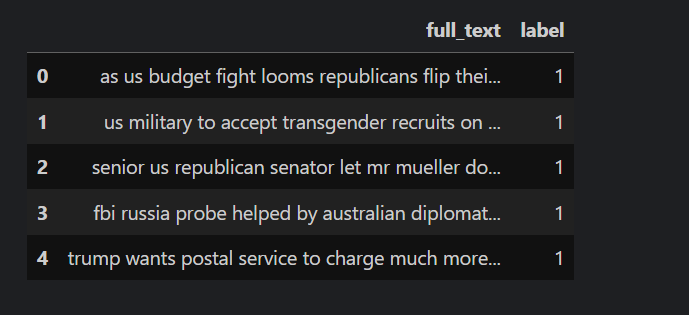
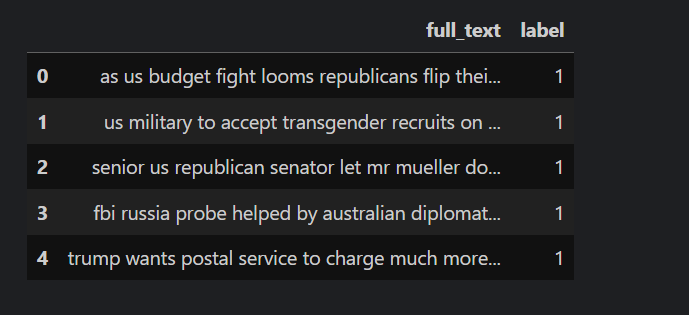

In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text.strip()

def load_and_prepare_news_data(true_path, fake_path, sample_size=None):
    df_true = pd.read_csv(true_path)
    df_fake = pd.read_csv(fake_path)

    df_true['label'] = 1
    df_fake['label'] = 0

    df = pd.concat([df_true, df_fake], ignore_index=True)

    if sample_size:
        df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

    df['full_text'] = df['title'] + " " + df['text']
    df['full_text'] = df['full_text'].apply(clean_text)

    print("First 5 rows of the combined dataset:")
    display(df[['full_text', 'label']].head())

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df['full_text'],
        df['label'].values,
        test_size=0.2,
        random_state=42
    )

    return X_train_raw.reset_index(drop=True), X_test_raw.reset_index(drop=True), y_train, y_test

X_train_raw, X_test_raw, y_train, y_test = load_and_prepare_news_data(
    true_path="data/True.csv",
    fake_path="data/Fake.csv",
    sample_size=2500
)

First 5 rows of the combined dataset:


,full_text,label
0,as us budget fight looms republicans flip thei...,1
1,us military to accept transgender recruits on ...,1
2,senior us republican senator let mr mueller do...,1
3,fbi russia probe helped by australian diplomat...,1
4,trump wants postal service to charge much more...,1


## Part 3 - Naive Bayes Learning Model Implementation
<p>Naive Bayes is a probabilistic classification algorithm built on <b>Bayes' Theorem</b>. It calculates the probability of a news article belonging to a specific class (e.g., <i>Fake</i> vs. <i>True</i>) based on the features (words and n-grams) it contains.</p>

<ul>
    <li><b>The "Naive" Assumption:</b> It assumes that all words in an article are completely independent of one another. While this isn't strictly true in human language, this simplification makes the model lightning-fast and surprisingly effective.</li>
    <li><b>The "Multinomial" Variant:</b> Specifically tailored for discrete frequency data (word counts or TF-IDF weights), making it ideal for text classification.</li>
    <li><b>Laplace Smoothing (&alpha;):</b> Acts as a smoothing hyperparameter to prevent zero-probability errors when the model encounters words in the test set that it never saw during training.</li>
</ul>

In [18]:
class CustomNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes = None
        self.class_priors = None
        self.feature_log_probs = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.class_priors = np.zeros(n_classes)
        self.feature_log_probs = np.zeros((n_classes, n_features))

        for i, c in enumerate(self.classes):
            X_c = X[y == c]

            self.class_priors[i] = np.log(len(X_c) / n_samples)

            feature_counts = np.sum(X_c, axis=0)
            total_count = np.sum(feature_counts)

            smoothed_probs = (feature_counts + self.alpha) / (total_count + self.alpha * n_features)
            self.feature_log_probs[i] = np.log(smoothed_probs)

    def predict(self, X):
        log_likelihoods = X @ self.feature_log_probs.T + self.class_priors
        class_indices = np.argmax(log_likelihoods, axis=1)
        return self.classes[class_indices]

## Part 2+4 - Model Training using K-Fold method on 2 Feature engineering methods
<p>This code section executes a comprehensive <b>5-Fold Cross-Validation Grid Search</b> to systematically compare our two feature engineering pipelines (TF-IDF and Bag of Words) across multiple hyperparameter combinations, followed by a final evaluation on the unseen test set.</p>

<ul>
    <li><b>Grid Search Optimization:</b> Evaluates performance across vectorizer types, vocabulary size limits (<code>max_features</code>), and Laplace smoothing weights (<code>alpha</code>) using 5-fold cross-validation (<code>random_state=42</code>) to ensure robust generalization.</li>
    <li><b>Comparative Feature Engineering:</b> Tests both raw term frequency counts (<code>CountVectorizer</code>) and weighted statistical importance (<code>TfidfVectorizer</code>), incorporating both unigrams and bigrams (<code>ngram_range=(1, 2)</code>).</li>
    <li><b>Data Leakage Prevention:</b> Vectorizers and models are initialized and fitted strictly within each cross-validation fold partition to maintain experimental integrity.</li>
    <li><b>Final Model Training &amp; Evaluation:</b> Automatically isolates the optimal configuration for both TF-IDF and BoW, trains final instances on the entire training corpus, and outputs a side-by-side comparison of their final F1-scores and accuracies on the test set.</li>
</ul>

In [19]:
print("\n----------------------\n")
print("Starting 5-Fold Grid Search (TF-IDF vs. Bag of Words)")
print("\n----------------------\n")

vectorizer_options = ['tfidf', 'bow']
alpha_options = [0.2, 0.4, 0.6, 0.8, 1.0]
max_features_options = [1500, 3000]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_results = []

X_train_strings = np.array(X_train_raw.astype(str))
y_train_np = np.array(y_train)

for vec_type in vectorizer_options:
    print("--- Running Vectorizer with option {} ---".format(vec_type))
    for max_feat in max_features_options:
        print("--- testing with max features cap of {} ---".format(max_feat))
        for alpha in alpha_options:
            print("--- testing with alpha value of {} ---".format(max_feat))
            fold_f1_scores = []

            for train_idx, val_idx in kf.split(X_train_strings):
                X_k_train_raw = X_train_strings[train_idx]
                X_k_val_raw = X_train_strings[val_idx]
                y_k_train = y_train_np[train_idx]
                y_k_val = y_train_np[val_idx]

                if vec_type == 'tfidf':
                    vec = TfidfVectorizer(stop_words='english', max_features=max_feat, ngram_range=(1, 2))
                else:
                    vec = CountVectorizer(stop_words='english', max_features=max_feat, ngram_range=(1, 2))

                X_k_train = vec.fit_transform(X_k_train_raw).toarray()
                X_k_val = vec.transform(X_k_val_raw).toarray()

                model = CustomNaiveBayes(alpha=alpha)
                model.fit(X_k_train, y_k_train)

                predictions = model.predict(X_k_val)
                fold_f1_scores.append(f1_score(y_k_val, predictions))

            grid_results.append({
                "type": vec_type,
                "max_features": max_feat,
                "alpha": alpha,
                "mean_f1_score": np.mean(fold_f1_scores)
            })

results_df = pd.DataFrame(grid_results)
display(results_df)


best_tfidf = results_df[results_df["type"] == "tfidf"].sort_values(by="mean_f1_score", ascending=False).iloc[0]
best_tfidf_max_feat = int(best_tfidf["Max_Features"])
best_tfidf_alpha = best_tfidf["Alpha"]

best_bow = results_df[results_df["Vectorizer"] == "bow"].sort_values(by="mean_f1_score", ascending=False).iloc[0]
best_bow_max_feat = int(best_bow["Max_Features"])
best_bow_alpha = best_bow["Alpha"]

print(f"\nBest TF-IDF Config Max Features: {best_tfidf_max_feat} | alpha: {best_tfidf_alpha}")
print(f"Best BoW Config Max Features: {best_bow_max_feat} | alpha: {best_bow_alpha}")



print("\n----------------------\n")
print("Training Final Models on Entire Train Set (TF-IDF vs BoW)")
print("\n----------------------\n\n")

print("\n---\nRunning Final TF-IDF Model...\n---\n")
vec_tfidf = TfidfVectorizer(stop_words='english', max_features=best_tfidf_max_feat, ngram_range=(1, 2))
X_train_tfidf = vec_tfidf.fit_transform(X_train_raw).toarray()
X_test_tfidf = vec_tfidf.transform(X_test_raw).toarray()

model_tfidf = CustomNaiveBayes(alpha=best_tfidf_alpha)
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

f1_tfidf = f1_score(y_test, y_pred_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)


print("\n---\nRunning Final Bag of Words (BoW) Model...\n---\n")
vec_bow = CountVectorizer(stop_words='english', max_features=best_bow_max_feat, ngram_range=(1, 2))
X_train_bow = vec_bow.fit_transform(X_train_raw).toarray()
X_test_bow = vec_bow.transform(X_test_raw).toarray()

model_bow = CustomNaiveBayes(alpha=best_bow_alpha)
model_bow.fit(X_train_bow, y_train)
y_pred_bow = model_bow.predict(X_test_bow)

f1_bow = f1_score(y_test, y_pred_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)

print("\n----------------------\n")
print("FINAL TEST METRICS COMPARISON")
print("\n----------------------\n")

print(f"TF-IDF Model F1-Score: {f1_tfidf:.4f} | Accuracy: {acc_tfidf:.4f}")
print(f"BoW Model F1-Score: {f1_bow:.4f} | Accuracy: {acc_bow:.4f}")

print("\n"
      "First 5 Predictions (TF-IDF):", y_pred_tfidf[:5])
print("First 5 Predictions (BoW):   ", y_pred_bow[:5])
print("First 5 Actual Labels:       ", y_test[:5])

=== Starting 5-Fold Grid Search (TF-IDF vs. Bag of Words) ===


,Vectorizer,Max_Features,Alpha,Mean_F1_Score
0,tfidf,1500,0.1,0.936219
1,tfidf,1500,1.0,0.934991
2,tfidf,3000,0.1,0.942588
3,tfidf,3000,1.0,0.940238
4,bow,1500,0.1,0.952358
5,bow,1500,1.0,0.951925
6,bow,3000,0.1,0.956146
7,bow,3000,1.0,0.955175



Best TF-IDF Config -> Max Features: 3000 | Alpha: 0.1
Best BoW Config    -> Max Features: 3000 | Alpha: 0.1

=== Training Final Models on Entire Train Set (TF-IDF vs BoW) ===

>>> Running Final TF-IDF Model...
>>> Running Final Bag of Words (BoW) Model...

=== FINAL TEST METRICS COMPARISON ===
TF-IDF Model -> F1-Score: 0.9490 | Accuracy: 0.9507
BoW Model    -> F1-Score: 0.9594 | Accuracy: 0.9606

First 5 Predictions (TF-IDF): [0 0 0 1 0]
First 5 Predictions (BoW):    [0 0 0 1 0]
First 5 Actual Labels:        [0 0 0 1 0]


## Word Cloud
<p>
    For better visualization of the data, we've presented our 200 highest unigrams/bigrams from the full train data in a handy wordcloud:
    <br>
    <img src="img/bow_wordcloud.png">
</p>


=== WordCloud from BoW data vector ===


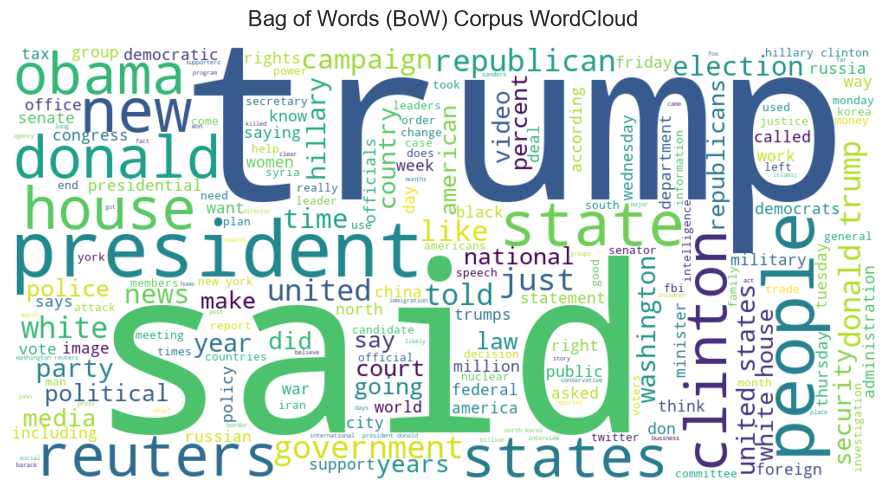

In [22]:
print("\n----------------------\n")
print("WordCloud from BoW data vector")
print("\n----------------------\n")

bow_feature_names = vec_bow.get_feature_names_out()
bow_word_counts = np.sum(X_train_bow, axis=0)

bow_word_freqs = dict(zip(bow_feature_names, bow_word_counts))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200
).generate_from_frequencies(bow_word_freqs)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Bag of Words (BoW) Corpus WordCloud", fontsize=16, pad=15)
plt.tight_layout()
plt.savefig("assets/bow_wordcloud.png")
plt.show()



## Part 5 - Model Prediction and Quality Review


=== Training Final Models on Entire Train Set (TF-IDF vs BoW) ===

>>> Running Final TF-IDF Model...
>>> Running Final Bag of Words (BoW) Model...

=== FINAL TEST METRICS COMPARISON ===
TF-IDF Model F1-Score: 0.9490 | Accuracy: 0.9507
BoW Model F1-Score: 0.9594 | Accuracy: 0.9606

First 5 Predictions (TF-IDF): [0 0 0 1 0]
First 5 Predictions (BoW):    [0 0 0 1 0]
First 5 Actual Labels:        [0 0 0 1 0]

=== Confusion Matrix Comparison (TF-IDF vs BoW) ===


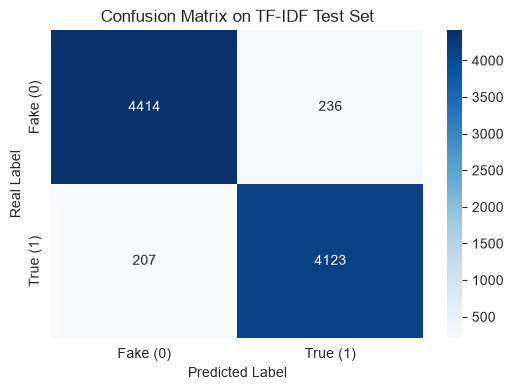

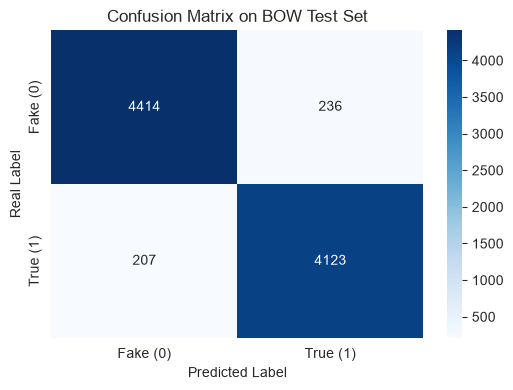


=== Highest Unigrams / Bigrams (TF-IDF/BoW) ===


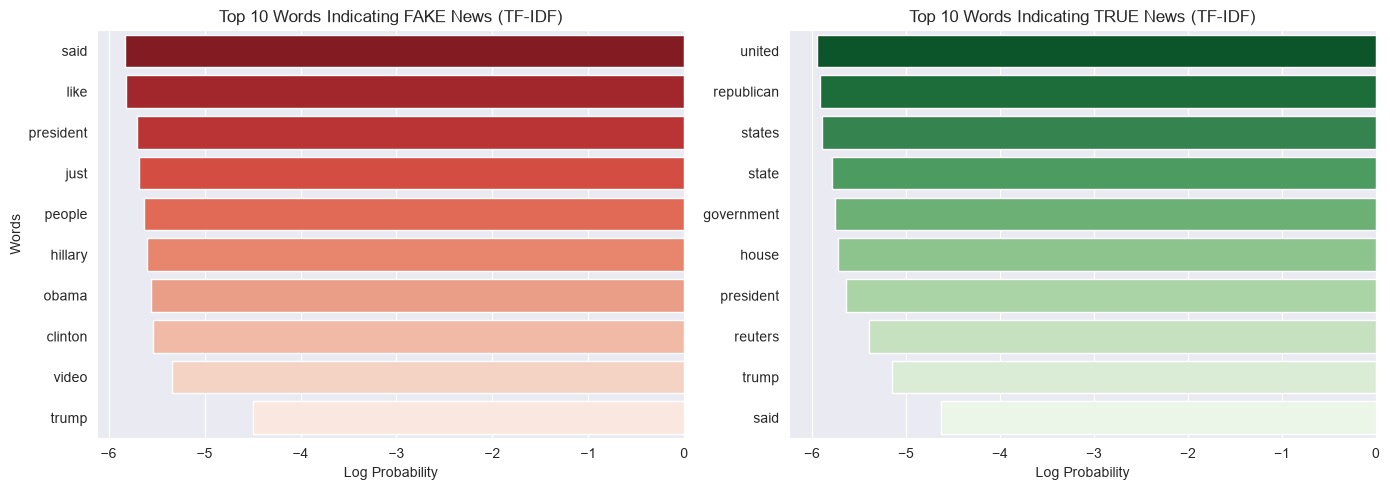

C:\Users\tzvib\AppData\Local\Temp\ipykernel_21916\4078907658.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fake_scores, y=top_fake_words, ax=axes[0], palette="Reds_r", legend=False)
C:\Users\tzvib\AppData\Local\Temp\ipykernel_21916\4078907658.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_true_scores, y=top_true_words, ax=axes[1], palette="Greens_r", legend=False)


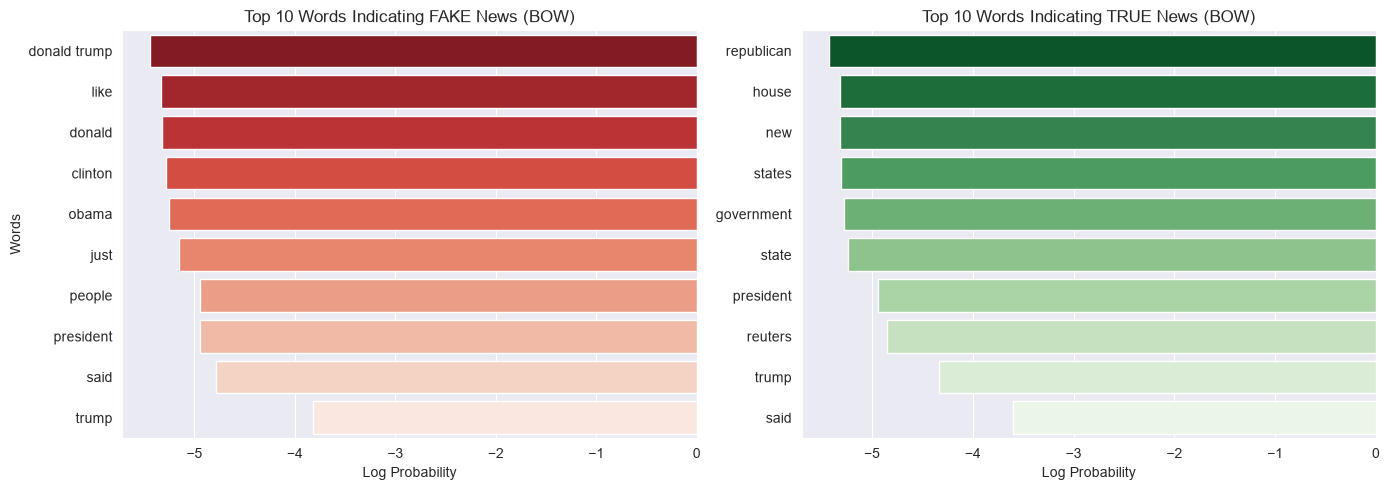

In [20]:
print("\n----------------------\n")
print("\nTraining Final Models on Entire Train Set (TF-IDF vs BoW)")

print("\n>>> Running Final TF-IDF Model...")
vec_tfidf = TfidfVectorizer(stop_words='english', max_features=best_tfidf_max_feat, ngram_range=(1, 2))
X_train_tfidf = vec_tfidf.fit_transform(X_train_raw).toarray()
X_test_tfidf = vec_tfidf.transform(X_test_raw).toarray()

model_tfidf = CustomNaiveBayes(alpha=best_tfidf_alpha)
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

f1_tfidf = f1_score(y_test, y_pred_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(">>> Running Final Bag of Words (BoW) Model...")
vec_bow = CountVectorizer(stop_words='english', max_features=best_bow_max_feat, ngram_range=(1, 2))
X_train_bow = vec_bow.fit_transform(X_train_raw).toarray()
X_test_bow = vec_bow.transform(X_test_raw).toarray()

model_bow = CustomNaiveBayes(alpha=best_bow_alpha)
model_bow.fit(X_train_bow, y_train)
y_pred_bow = model_bow.predict(X_test_bow)

f1_bow = f1_score(y_test, y_pred_bow)
acc_bow = accuracy_score(y_test, y_pred_bow)


print("\n=== FINAL TEST METRICS COMPARISON ===")
print(f"TF-IDF Model F1-Score: {f1_tfidf:.4f} | Accuracy: {acc_tfidf:.4f}")
print(f"BoW Model F1-Score: {f1_bow:.4f} | Accuracy: {acc_bow:.4f}")

print("\n"
      "First 5 Predictions (TF-IDF):", y_pred_tfidf[:5])
print("First 5 Predictions (BoW):   ", y_pred_bow[:5])
print("First 5 Actual Labels:       ", y_test[:5])

print("\n=== Confusion Matrix Comparison (TF-IDF vs BoW) ===")
tfidf_cm = confusion_matrix(y_test, y_pred_tfidf)
bow_cm = confusion_matrix(y_test, y_pred_bow)

plt.figure(figsize=(6, 4))
sns.heatmap(tfidf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'True (1)'],
            yticklabels=['Fake (0)', 'True (1)'])
plt.title("Confusion Matrix on TF-IDF Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Real Label")
plt.savefig("assets/confusion_matrix_tfidf.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(tfidf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'True (1)'],
            yticklabels=['Fake (0)', 'True (1)'])
plt.title("Confusion Matrix on BOW Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("Real Label")
plt.savefig("assets/confusion_matrix_bow.png")
plt.show()


print("\n=== Highest Unigrams / Bigrams (TF-IDF/BoW) ===")
#TF-IDF
feature_names_tfidf = vec_tfidf.get_feature_names_out()

fake_log_probs_tfidf = model_tfidf.feature_log_probs[0]
true_log_probs_tfidf = model_tfidf.feature_log_probs[1]

top_fake_idx_tfidf = np.argsort(fake_log_probs_tfidf)[-10:]
top_true_idx_tfidf = np.argsort(true_log_probs_tfidf)[-10:]

top_fake_words_tfidf = [feature_names_tfidf[i] for i in top_fake_idx_tfidf]
top_fake_scores_tfidf = [fake_log_probs_tfidf[i] for i in top_fake_idx_tfidf]

top_true_words_tfidf = [feature_names_tfidf[i] for i in top_true_idx_tfidf]
top_true_scores_tfidf = [true_log_probs_tfidf[i] for i in top_true_idx_tfidf]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_fake_scores_tfidf, y=top_fake_words_tfidf, ax=axes[0], hue=top_fake_words_tfidf, palette="Reds_r", legend=False)
axes[0].set_title("Top 10 Words Indicating FAKE News (TF-IDF)")
axes[0].set_xlabel("Log Probability")
axes[0].set_ylabel("Words")

sns.barplot(x=top_true_scores_tfidf, y=top_true_words_tfidf, ax=axes[1], hue=top_true_words_tfidf, palette="Greens_r", legend=False)
axes[1].set_title("Top 10 Words Indicating TRUE News (TF-IDF)")
axes[1].set_xlabel("Log Probability")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("assets/true_fake_log_chart_tfidf.png")
plt.show()

#Bag of Words
feature_names = vec_bow.get_feature_names_out()

fake_log_probs = model_bow.feature_log_probs[0]
true_log_probs = model_bow.feature_log_probs[1]

top_fake_idx = np.argsort(fake_log_probs)[-10:]
top_true_idx = np.argsort(true_log_probs)[-10:]

top_fake_words = [feature_names[i] for i in top_fake_idx]
top_fake_scores = [fake_log_probs[i] for i in top_fake_idx]

top_true_words = [feature_names[i] for i in top_true_idx]
top_true_scores = [true_log_probs[i] for i in top_true_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fake News Chart
sns.barplot(x=top_fake_scores, y=top_fake_words, ax=axes[0], palette="Reds_r", legend=False)
axes[0].set_title("Top 10 Words Indicating FAKE News (BOW)")
axes[0].set_xlabel("Log Probability")
axes[0].set_ylabel("Words")

# True News Chart
sns.barplot(x=top_true_scores, y=top_true_words, ax=axes[1], palette="Greens_r", legend=False)
axes[1].set_title("Top 10 Words Indicating TRUE News (BOW)")
axes[1].set_xlabel("Log Probability")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("assets/true_fake_log_chart_bow.png")
plt.show()

## Final conclusions

On the full data set, we've seen the following differences between TF-IDF and BOW feature engineering sets:
The results show a slight improvment of results when the data is run with a count-vectorizer, which coincides with the naive bayes methodology of working with straight probabilities with the assumption of no corrolation between the tested features.

<br>
TF-IDF Model F1-Score: 0.9490 | Accuracy: 0.9507
<br>
BoW Model F1-Score: 0.9594 | Accuracy: 0.9606
<br>
<p>
First 5 Predictions (TF-IDF): [0 0 0 1 0]
<br>
First 5 Predictions (BoW):    [0 0 0 1 0]
<br>
First 5 Actual Labels:        [0 0 0 1 0]
</p>

### Confusion matrices comparison
<div>
    <img src="img/confusion_matrix_tfidf.png">
    <img src="img/confusion_matrix_bow.png">
</div>

### Highest unigram / bigram log correlation for binary classification
<img src="img/true_fake_log_chart_tfidf.png">
<img src="img/true_fake_log_chart_bow.png">



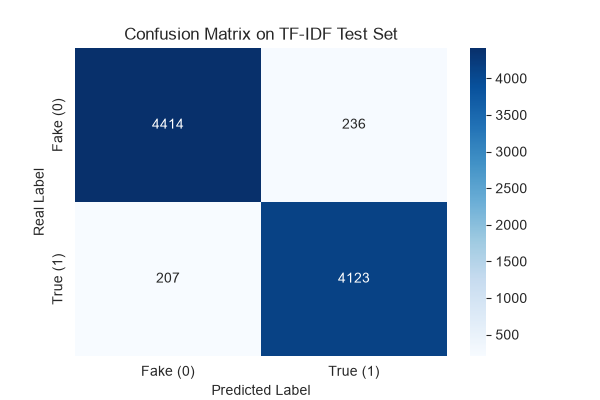